In [1]:
import numpy as np
import pickle, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cpu')

# ── Load LSTM ──────────────────────────────────────────
class RULPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, batch_first=True,
                            dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)

with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

lstm_model = RULPredictor(input_size=len(feature_cols))
lstm_model.load_state_dict(torch.load(
    '../models/lstm_best.pt', map_location=device))
lstm_model.eval()

# ── Load NLP ───────────────────────────────────────────
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open('../models/nlp_classifier.pkl', 'rb') as f:
    nlp_model = pickle.load(f)
with open('../models/nlp_metadata.pkl', 'rb') as f:
    nlp_meta = pickle.load(f)

# ── Load CNN ───────────────────────────────────────────
cnn_model = models.resnet18(weights=None)
cnn_model.fc = nn.Sequential(
    nn.Linear(cnn_model.fc.in_features, 64),
    nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 3)
)
cnn_model.load_state_dict(torch.load(
    '../models/cnn_best.pt', map_location=device))
cnn_model.eval()

with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("✅ All 3 models loaded successfully")
print(f"   LSTM    → RUL predictor")
print(f"   NLP     → Fault classifier ({nlp_meta['model_name']})")
print(f"   CNN     → Image defect detector (ResNet18)")

✅ All 3 models loaded successfully
   LSTM    → RUL predictor
   NLP     → Fault classifier (Logistic Regression)
   CNN     → Image defect detector (ResNet18)


In [2]:
normalize_img = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)
CNN_CLASSES = ['healthy', 'worn', 'damaged']
FAULT_TYPES = nlp_meta['fault_types']
id_to_fault = nlp_meta['id_to_fault']

def lstm_predict(sensor_window):
    """sensor_window: (30, n_features) numpy array → predicted RUL"""
    t = torch.tensor(sensor_window, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        rul = lstm_model(t).item()
    return max(0.0, min(125.0, rul))

def nlp_predict(log_text):
    """log_text: string → (fault_type, confidence 0-1)"""
    vec   = tfidf.transform([log_text])
    pred  = nlp_model.predict(vec)[0]
    proba = nlp_model.predict_proba(vec)[0]
    return id_to_fault[pred], proba[pred]

def cnn_predict(img_array):
    """img_array: (64,64) numpy → (condition, confidence 0-1)"""
    t = torch.tensor(img_array, dtype=torch.float32)
    t = normalize_img(t.unsqueeze(0).repeat(3, 1, 1)).unsqueeze(0)
    with torch.no_grad():
        proba = torch.nn.functional.softmax(
            cnn_model(t), dim=1)[0].numpy()
    pred = proba.argmax()
    return CNN_CLASSES[pred], proba[pred]

print("✅ Inference functions ready")

✅ Inference functions ready


In [3]:
def fuse_predictions(rul, fault_type, nlp_conf,
                       cnn_condition, cnn_conf):
    """
    Combines outputs from all 3 models into a single
    unified risk score (0-100) and maintenance decision.

    Weights reflect each model's reliability:
      LSTM  → 50%  (real sensor data, best metric)
      NLP   → 25%  (text classification)
      CNN   → 25%  (image classification)
    """
    # ── LSTM score: lower RUL = higher risk ──────────
    lstm_risk = (1.0 - rul / 125.0) * 100

    # ── NLP score: severe faults = higher risk ───────
    fault_severity = {
        'turbine_blade_damage'   : 95,
        'bearing_wear'           : 75,
        'compressor_degradation' : 65,
        'fuel_system'            : 55,
        'sensor_drift'           : 30,
    }
    nlp_risk = fault_severity.get(fault_type, 50) * nlp_conf

    # ── CNN score: condition → risk ───────────────────
    cnn_severity = {'healthy': 5, 'worn': 55, 'damaged': 90}
    cnn_risk = cnn_severity[cnn_condition] * cnn_conf

    # ── Weighted fusion ───────────────────────────────
    final_risk = (0.50 * lstm_risk +
                  0.25 * nlp_risk  +
                  0.25 * cnn_risk)
    final_risk = round(float(np.clip(final_risk, 0, 100)), 1)

    # ── Business decision ─────────────────────────────
    if   final_risk >= 75: status = "🔴 CRITICAL";  action = "Ground engine immediately"
    elif final_risk >= 50: status = "🟡 WARNING";   action = "Schedule maintenance this week"
    elif final_risk >= 25: status = "🟢 MONITOR";   action = "Inspect at next service interval"
    else:                   status = "✅ HEALTHY";   action = "No action required"

    return {
        'risk_score'    : final_risk,
        'status'        : status,
        'action'        : action,
        'lstm_risk'     : round(lstm_risk, 1),
        'nlp_risk'      : round(nlp_risk,  1),
        'cnn_risk'      : round(cnn_risk,  1),
        'rul'           : round(rul, 1),
        'fault_type'    : fault_type,
        'cnn_condition' : cnn_condition,
    }

print("✅ Fusion engine defined")

✅ Fusion engine defined


In [4]:
def full_pipeline(sensor_window, log_text, img_array,
                   engine_id="ENG-001", verbose=True):
    """
    Complete multimodal prediction for one engine.
    Takes sensor data + maintenance log + part image.
    Returns unified risk assessment.
    """
    # Run all 3 models
    rul            = lstm_predict(sensor_window)
    fault, nlp_c   = nlp_predict(log_text)
    cond,  cnn_c   = cnn_predict(img_array)

    # Fuse into one score
    result = fuse_predictions(rul, fault, nlp_c, cond, cnn_c)

    if verbose:
        print(f"\n{'═'*55}")
        print(f"  ENGINE HEALTH REPORT — {engine_id}")
        print(f"{'═'*55}")
        print(f"  LSTM  → RUL: {rul:.1f} cycles    Risk: {result['lstm_risk']:.1f}/100")
        print(f"  NLP   → Fault: {fault:24} Risk: {result['nlp_risk']:.1f}/100")
        print(f"  CNN   → Condition: {cond:20} Risk: {result['cnn_risk']:.1f}/100")
        print(f"{'─'*55}")
        print(f"  FUSED RISK SCORE : {result['risk_score']}/100")
        print(f"  STATUS           : {result['status']}")
        print(f"  ACTION           : {result['action']}")
        print(f"{'═'*55}\n")

    return result

print("✅ Full pipeline ready")

✅ Full pipeline ready


In [5]:
import random
random.seed(42)
np.random.seed(42)

# Load real sensor sequences from Phase 1
X_train = np.load('../data/X_train.npy')

# Helper to make test images (same as Phase 4)
def make_img(kind):
    img = np.random.normal(
        {'healthy':0.6,'worn':0.45,'damaged':0.35}[kind],
        0.08, (64, 64))
    if kind == 'worn':
        for _ in range(4):
            r = np.random.randint(10,54)
            img[r:r+2, 10:50] = 0.2
    elif kind == 'damaged':
        for _ in range(3):
            x,y = np.random.randint(10,50,2)
            img[x:x+8,y:y+8] = 0.05
    return np.clip(img, 0, 1)

# 4 realistic test scenarios
scenarios = [
    {
        'id'     : 'ENG-001',
        'sensor' : X_train[17000],   # near end of life
        'log'    : "Turbine blade tip clearance out of spec, crack found",
        'img'    : make_img('damaged'),
        'desc'   : 'Critical — near failure'
    },
    {
        'id'     : 'ENG-002',
        'sensor' : X_train[8000],    # mid life
        'log'    : "Bearing temperature elevated, lubrication topped up",
        'img'    : make_img('worn'),
        'desc'   : 'Warning — mid degradation'
    },
    {
        'id'     : 'ENG-003',
        'sensor' : X_train[1000],    # early life
        'log'    : "Pressure sensor showing slight offset, recalibrated",
        'img'    : make_img('healthy'),
        'desc'   : 'Healthy — early life'
    },
    {
        'id'     : 'ENG-004',
        'sensor' : X_train[12000],   # late life
        'log'    : "Compressor surge event, inlet guide vanes adjusted",
        'img'    : make_img('worn'),
        'desc'   : 'Monitor — late life'
    },
]

results = []
for s in scenarios:
    r = full_pipeline(s['sensor'], s['log'], s['img'],
                       engine_id=s['id'])
    r['engine_id'] = s['id']
    r['desc']      = s['desc']
    results.append(r)


═══════════════════════════════════════════════════════
  ENGINE HEALTH REPORT — ENG-001
═══════════════════════════════════════════════════════
  LSTM  → RUL: 7.6 cycles    Risk: 94.0/100
  NLP   → Fault: turbine_blade_damage     Risk: 86.6/100
  CNN   → Condition: healthy              Risk: 2.0/100
───────────────────────────────────────────────────────
  FUSED RISK SCORE : 69.1/100
  STATUS           : 🟡 WARNING
  ACTION           : Schedule maintenance this week
═══════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  ENGINE HEALTH REPORT — ENG-002
═══════════════════════════════════════════════════════
  LSTM  → RUL: 89.3 cycles    Risk: 28.6/100
  NLP   → Fault: bearing_wear             Risk: 57.0/100
  CNN   → Condition: worn                 Risk: 55.0/100
───────────────────────────────────────────────────────
  FUSED RISK SCORE : 42.3/100
  STATUS           : 🟢 MONITOR
  ACTION           : Inspect at next service inte

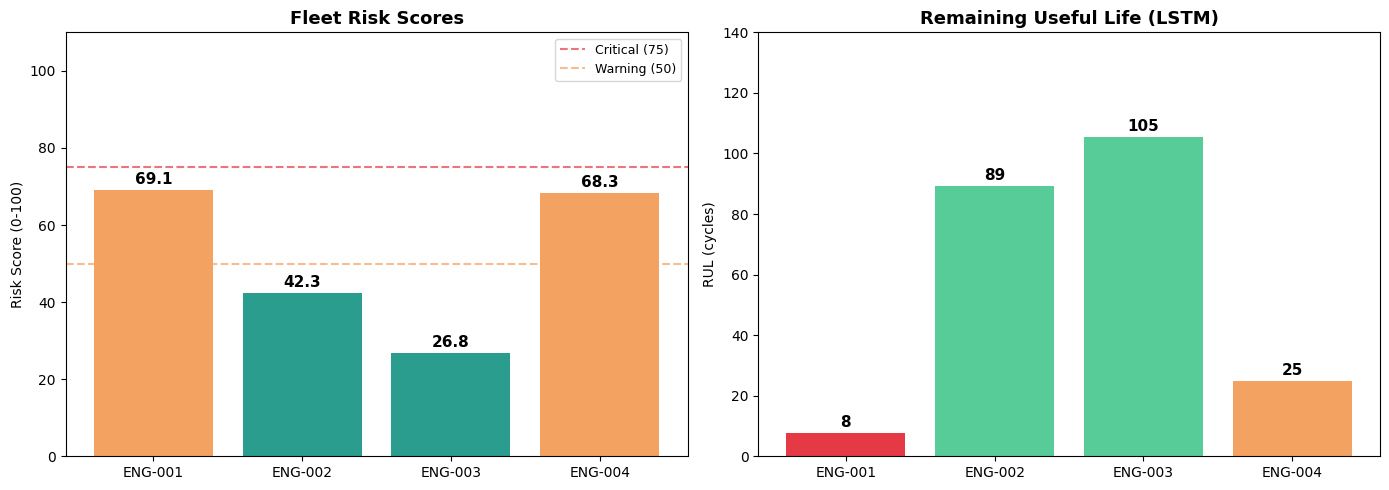

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

engine_ids  = [r['engine_id']  for r in results]
risk_scores = [r['risk_score'] for r in results]
rul_values  = [r['rul']        for r in results]

bar_colors = [
    '#e63946' if s >= 75 else
    '#f4a261' if s >= 50 else
    '#2a9d8f' if s >= 25 else '#57cc99'
    for s in risk_scores
]

# Risk score bar chart
bars = axes[0].bar(engine_ids, risk_scores,
                   color=bar_colors, edgecolor='none')
axes[0].axhline(75, color='#e63946', linestyle='--',
                alpha=0.7, label='Critical (75)')
axes[0].axhline(50, color='#f4a261', linestyle='--',
                alpha=0.7, label='Warning (50)')
axes[0].set_ylim(0, 110)
axes[0].set_title('Fleet Risk Scores', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Risk Score (0-100)')
axes[0].legend(fontsize=9)
for bar, score in zip(bars, risk_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 1.5,
               f'{score}', ha='center', fontsize=11, fontweight='bold')

# RUL bar chart
rul_colors = ['#e63946' if r <= 20 else
              '#f4a261' if r <= 50 else '#57cc99'
              for r in rul_values]
axes[1].bar(engine_ids, rul_values,
            color=rul_colors, edgecolor='none')
axes[1].set_title('Remaining Useful Life (LSTM)',
                   fontweight='bold', fontsize=13)
axes[1].set_ylabel('RUL (cycles)')
axes[1].set_ylim(0, 140)
for i, (eng, rul) in enumerate(zip(engine_ids, rul_values)):
    axes[1].text(i, rul + 2, f'{rul:.0f}',
               ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot12_fleet_dashboard.png', dpi=120)
plt.show()

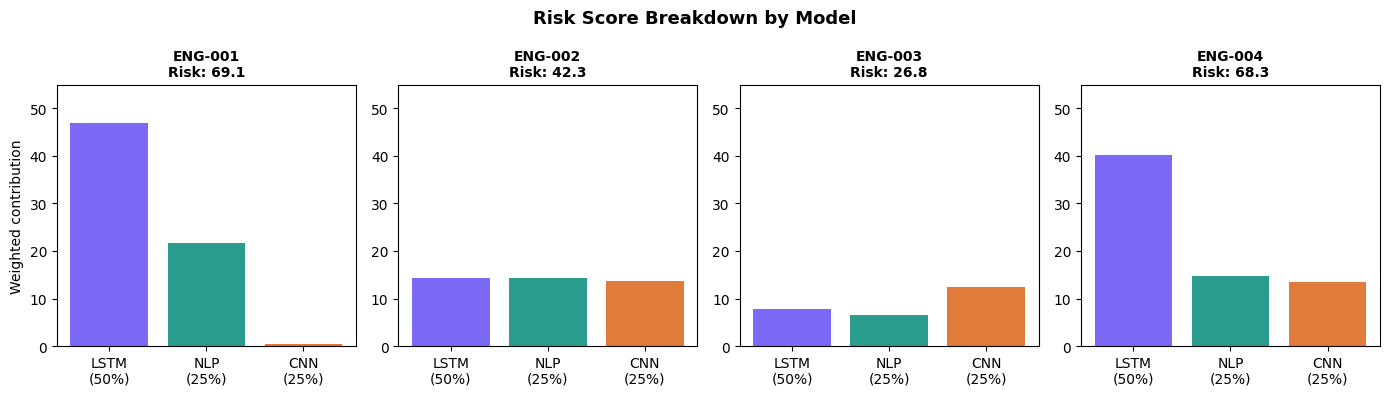

In [7]:
# Show how each model contributed to the final risk score
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, (r, ax) in enumerate(zip(results, axes)):
    components = [
        r['lstm_risk'] * 0.5,
        r['nlp_risk']  * 0.25,
        r['cnn_risk']  * 0.25,
    ]
    labels = ['LSTM\n(50%)', 'NLP\n(25%)', 'CNN\n(25%)']
    colors = ['#7c6af7', '#2a9d8f', '#e07b39']
    ax.bar(labels, components, color=colors, edgecolor='none')
    ax.set_title(f"{r['engine_id']}\nRisk: {r['risk_score']}",
                fontweight='bold', fontsize=10)
    ax.set_ylim(0, 55)
    ax.set_ylabel('Weighted contribution' if i == 0 else '')

plt.suptitle('Risk Score Breakdown by Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot13_contribution.png', dpi=120)
plt.show()

In [8]:
import pandas as pd

# Save results as CSV for the dashboard
df_results = pd.DataFrame(results)
df_results.to_csv('../data/fusion_results.csv', index=False)

# Save fusion config for dashboard
fusion_config = {
    'weights'     : {'lstm': 0.5, 'nlp': 0.25, 'cnn': 0.25},
    'thresholds'  : {'critical': 75, 'warning': 50, 'monitor': 25},
    'rul_cap'     : 125,
    'fault_severity': {
        'turbine_blade_damage'  : 95,
        'bearing_wear'          : 75,
        'compressor_degradation': 65,
        'fuel_system'           : 55,
        'sensor_drift'          : 30,
    }
}
with open('../models/fusion_config.json', 'w') as f:
    json.dump(fusion_config, f, indent=2)

print("✅ Phase 5 complete! Saved:")
print("   data/fusion_results.csv")
print("   models/fusion_config.json")
print("\n📊 Fleet Summary:")
print("─" * 50)
for r in results:
    print(f"  {r['engine_id']} │ Risk: {r['risk_score']:5.1f} │ {r['status']}")
print("\n🚀 Ready for Phase 6 — Streamlit Dashboard!")

✅ Phase 5 complete! Saved:
   data/fusion_results.csv
   models/fusion_config.json

📊 Fleet Summary:
──────────────────────────────────────────────────
  ENG-001 │ Risk:  69.1 │ 🟡 WARNING
  ENG-002 │ Risk:  42.3 │ 🟢 MONITOR
  ENG-003 │ Risk:  26.8 │ 🟢 MONITOR
  ENG-004 │ Risk:  68.3 │ 🟡 WARNING

🚀 Ready for Phase 6 — Streamlit Dashboard!


In [9]:
# Try your own scenario — change these values!
MY_ENGINE_ID  = "MY-ENG-001"
MY_LOG        = "Unusual vibration in bearing housing, noise increasing"
MY_IMG_TYPE   = "healthy"   # change to: 'healthy', 'worn', 'damaged'
MY_SEQ_IDX    = 13000   # change 0-17630 (higher = more degraded)

result = full_pipeline(
    sensor_window = X_train[MY_SEQ_IDX],
    log_text      = MY_LOG,
    img_array     = make_img(MY_IMG_TYPE),
    engine_id     = MY_ENGINE_ID
)

print(f"Try changing MY_SEQ_IDX, MY_LOG, and MY_IMG_TYPE")
print(f"to see how the risk score changes!")


═══════════════════════════════════════════════════════
  ENGINE HEALTH REPORT — MY-ENG-001
═══════════════════════════════════════════════════════
  LSTM  → RUL: 80.3 cycles    Risk: 35.8/100
  NLP   → Fault: bearing_wear             Risk: 69.1/100
  CNN   → Condition: worn                 Risk: 44.0/100
───────────────────────────────────────────────────────
  FUSED RISK SCORE : 46.2/100
  STATUS           : 🟢 MONITOR
  ACTION           : Inspect at next service interval
═══════════════════════════════════════════════════════

Try changing MY_SEQ_IDX, MY_LOG, and MY_IMG_TYPE
to see how the risk score changes!
